In [1]:
!pip3 install imbalanced-learn


[notice] A new release of pip is available: 24.2 -> 24.3.1
[notice] To update, run: python3 -m pip install --upgrade pip


2025-01-01 20:19:29.577706: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-01 20:19:30.258460: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2025-01-01 20:19:30.258548: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /usr/local/nvidia/lib:/usr/local/nvidia/lib64
2025-01-01 20:19:30.258557: W tensorfl

Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


2025-01-01 20:19:31.886980: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-01-01 20:19:31.947342: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-01-01 20:19:31.947533: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-01-01 20:19:31.948148: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorF

29084464/29084464 [==============================] - 0s 0us/step
Starting time: 20250101_201934
Epoch 1/100


2025-01-01 20:19:50.829317: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:428] Loaded cuDNN version 8906
2025-01-01 20:19:51.362947: I tensorflow/compiler/xla/service/service.cc:173] XLA service 0x7cefc0145c20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-01-01 20:19:51.362982: I tensorflow/compiler/xla/service/service.cc:181]   StreamExecutor device (0): NVIDIA GeForce GTX 1080 Ti, Compute Capability 6.1
2025-01-01 20:19:51.366666: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-01-01 20:19:51.434932: I tensorflow/compiler/jit/xla_compilation_cache.cc:477] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


101/101 [==============================] - 4s 30ms/step
Epoch 1 - val_precision: 0.6803, val_recall (Sensitivity): 0.8896, val_f1_score: 0.7710, val_auc_pr: 0.7464, val_specificity: 0.5819, val_mcc: 0.4955
807/807 [==============================] - 146s 136ms/step - loss: 1.1433 - binary_accuracy: 0.5504 - precision: 0.5421 - recall: 0.6496 - auc: 0.5695 - val_loss: 0.5651 - val_binary_accuracy: 0.7357 - val_precision: 0.6803 - val_recall: 0.8896 - val_auc: 0.8046 - lr: 1.0000e-06 - val_f1_score: 0.7710 - val_auc_pr: 0.7464 - val_mcc: 0.4955 - val_specificity: 0.5819
Epoch 2/100
101/101 [==============================] - 3s 30ms/step
Epoch 2 - val_precision: 0.7063, val_recall (Sensitivity): 0.9429, val_f1_score: 0.8077, val_auc_pr: 0.7898, val_specificity: 0.6079, val_mcc: 0.5846
807/807 [==============================] - 107s 133ms/step - loss: 0.8698 - binary_accuracy: 0.6467 - precision: 0.6148 - recall: 0.7862 - auc: 0.7062 - val_loss: 0.4993 - val_binary_accuracy: 0.7754 - val_pr

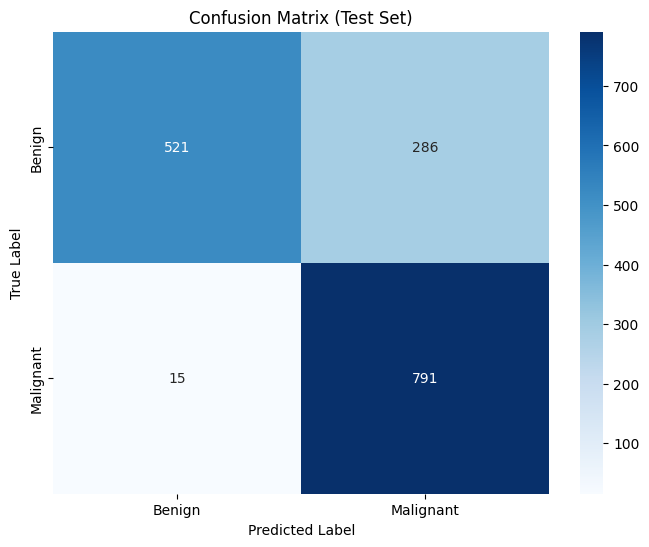

In [2]:
import tensorflow as tf
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler, ModelCheckpoint, Callback
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve, auc, matthews_corrcoef
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from imblearn.over_sampling import RandomOverSampler


# Set image size and directories
img_size = (224, 224)  # Updated for DenseNet121

data_dir = '/workspace/data/raw'
model_dir = '/workspace/models'
os.makedirs(model_dir, exist_ok=True)
tables_dir = '/workspace/tables'
os.makedirs(tables_dir, exist_ok=True)

# Load metadata
csv_file = os.path.join(data_dir, 'HAM10000_metadata.csv')
metadata = pd.read_csv(csv_file)

# Map the original labels to binary labels: benign (0) and malignant (1)
benign_labels = ['nv', 'bkl', 'df','vasc']
malignant_labels = ['mel', 'bcc', 'akiec']

metadata['binary_label'] = metadata['dx'].apply(lambda x: 0 if x in benign_labels else 1)
metadata['image_path'] = metadata['image_id'].apply(lambda x: os.path.join(data_dir, f'{x}.jpg'))

# Oversample the data for balanced binary classification
ros = RandomOverSampler(random_state=42)
resampled_data, resampled_labels = ros.fit_resample(metadata[['image_path', 'binary_label']], metadata['binary_label'])
metadata_resampled = pd.DataFrame(resampled_data, columns=['image_path', 'binary_label'])

# Split into training (80%), validation (10%), and testing (10%)
train_metadata, temp_metadata = train_test_split(metadata_resampled, test_size=0.2, stratify=metadata_resampled['binary_label'], random_state=42)
val_metadata, test_metadata = train_test_split(temp_metadata, test_size=0.5, stratify=temp_metadata['binary_label'], random_state=42)

# Function to load and preprocess images
def load_image(image_path, label, augment=False):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, img_size)
    if augment:
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_flip_up_down(image)
        image = tf.image.random_brightness(image, max_delta=0.2)
        image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = image / 255.0  # Normalize to [0, 1]
    return image, label

# Create TensorFlow datasets
def create_dataset(metadata, batch_size=32, augment=False):
    image_paths = metadata['image_path'].values
    labels = metadata['binary_label'].values
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(lambda x, y: load_image(x, y, augment), num_parallel_calls=tf.data.experimental.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
    return dataset

batch_size = 16
train_dataset = create_dataset(train_metadata, batch_size=batch_size, augment=True)
val_dataset = create_dataset(val_metadata, batch_size=batch_size, augment=False)
test_dataset = create_dataset(test_metadata, batch_size=batch_size, augment=False)

# Compute class weights
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(metadata['binary_label']), y=metadata['binary_label'])
class_weights = dict(enumerate(class_weights))

# Load pre-trained DenseNet121 model
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

# Fine-tune the base model
for layer in base_model.layers[-100:]:
    layer.trainable = True

# Compile the model
initial_learning_rate = 0.000001
model.compile(optimizer=Adam(learning_rate=initial_learning_rate),
              loss='binary_crossentropy',
              metrics=[tf.keras.metrics.BinaryAccuracy(name='binary_accuracy'),
                       tf.keras.metrics.Precision(name='precision'),
                       tf.keras.metrics.Recall(name='recall'),
                       tf.keras.metrics.AUC(name='auc')])

# Learning rate scheduler
def lr_scheduler(epoch, lr):
    if epoch > 5:
        lr = lr * tf.math.exp(-0.1)
    return lr

lr_callback = LearningRateScheduler(lr_scheduler)

# Custom callback for metrics
class BinaryPerformanceMetricsCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        val_probs = model.predict(val_dataset)
        val_preds = (val_probs > 0.5).astype(int).squeeze()
        true_labels = np.concatenate([y for x, y in val_dataset], axis=0)
        
        # Compute metrics
        precision = precision_score(true_labels, val_preds)
        recall = recall_score(true_labels, val_preds)  # Sensitivity
        f1 = f1_score(true_labels, val_preds)
        mcc = matthews_corrcoef(true_labels, val_preds)
        specificity = confusion_matrix(true_labels, val_preds)[0, 0] / sum(confusion_matrix(true_labels, val_preds)[0])
        precision_vals, recall_vals, _ = precision_recall_curve(true_labels, val_probs)
        auc_pr = auc(recall_vals, precision_vals)

        logs['val_precision'] = precision
        logs['val_recall'] = recall
        logs['val_f1_score'] = f1
        logs['val_auc_pr'] = auc_pr
        logs['val_mcc'] = mcc
        logs['val_specificity'] = specificity

        print(f"Epoch {epoch + 1} - val_precision: {precision:.4f}, val_recall (Sensitivity): {recall:.4f}, "
              f"val_f1_score: {f1:.4f}, val_auc_pr: {auc_pr:.4f}, val_specificity: {specificity:.4f}, val_mcc: {mcc:.4f}")

# Define callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
checkpoint_filepath = os.path.join(model_dir, f"model_best_{datetime.now().strftime('%Y%m%d_%H%M%S')}.h5")
checkpoint_callback = ModelCheckpoint(filepath=checkpoint_filepath, monitor='val_loss', save_best_only=True)


# Train the model
print(f"Starting time: {datetime.now().strftime('%Y%m%d_%H%M%S')}")
history = model.fit(train_dataset, validation_data=val_dataset, epochs=100,
                    callbacks=[early_stopping, lr_callback, checkpoint_callback, BinaryPerformanceMetricsCallback()],
                    class_weight=class_weights)

# Save the final model
final_model_path = os.path.join(model_dir, f'model_final_{datetime.now().strftime("%Y%m%d_%H%M%S")}.h5')
model.save(final_model_path)
print(f"Model saved as {final_model_path}")
model_name = os.path.basename(final_model_path).replace('.h5', '')


# Evaluate on the test dataset
test_probs = model.predict(test_dataset)
test_preds = (test_probs > 0.5).astype(int).squeeze()
true_test_labels = np.concatenate([y for x, y in test_dataset], axis=0)

# Metrics on the test set
test_precision = precision_score(true_test_labels, test_preds)
test_recall = recall_score(true_test_labels, test_preds)  # Sensitivity
test_f1 = f1_score(true_test_labels, test_preds)
test_mcc = matthews_corrcoef(true_test_labels, test_preds)
test_specificity = confusion_matrix(true_test_labels, test_preds)[0, 0] / sum(confusion_matrix(true_test_labels, test_preds)[0])
test_auc_roc = roc_auc_score(true_test_labels, test_probs)
precision_vals, recall_vals, _ = precision_recall_curve(true_test_labels, test_probs)
test_auc_pr = auc(recall_vals, precision_vals)

# Display metrics ordered by importance
print(f"Test Sensitivity (Recall): {test_recall:.4f}")
print(f"Test Specificity: {test_specificity:.4f}")
print(f"Test AUC-PR: {test_auc_pr:.4f}")
print(f"Test AUC-ROC: {test_auc_roc:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test MCC: {test_mcc:.4f}")

# Confusion matrix for the test set
test_conf_matrix = confusion_matrix(true_test_labels, test_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(test_conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (Test Set)')
plt.show()


In [3]:
# Classification report
print("Classification Report:")
print(classification_report(true_test_labels, test_preds, target_names=['Benign', 'Malignant']))


Classification Report:
              precision    recall  f1-score   support

      Benign       0.97      0.65      0.78       807
   Malignant       0.73      0.98      0.84       806

    accuracy                           0.81      1613
   macro avg       0.85      0.81      0.81      1613
weighted avg       0.85      0.81      0.81      1613



In [4]:

# Generate a detailed classification report
class_report = classification_report(
    true_test_labels,  # Updated to use test labels
    test_preds,        # Updated to use test predictions
    target_names=['Benign', 'Malignant'], 
    output_dict=True
)

# Convert classification report to DataFrame for better visualization
report_df = pd.DataFrame(class_report).transpose()

# Calculate AUC score
auc_score = roc_auc_score(true_test_labels, test_probs)  # Updated to use test probabilities

# Add AUC to the overall metrics in the classification report
report_df.loc['AUC'] = ['', '', '', auc_score]

# Save the classification report to a CSV file
classification_report_path = os.path.join(tables_dir, f'classification_report_test_{model_name}.csv')
report_df.to_csv(classification_report_path, index=True)
print(f"Classification report saved to {classification_report_path}")


Classification report saved to /workspace/tables/classification_report_test_model_final_20250101_221336.csv


In [5]:
# Initialize a list to hold the metric rows
table_rows = []

# Function to calculate sensitivity and specificity
def calculate_sensitivity_specificity(y_true, y_pred):
    TP = sum((y_true == 1) & (y_pred == 1))
    TN = sum((y_true == 0) & (y_pred == 0))
    FP = sum((y_true == 0) & (y_pred == 1))
    FN = sum((y_true == 1) & (y_pred == 0))

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    return sensitivity, specificity

# Overall metrics
overall_sensitivity, overall_specificity = calculate_sensitivity_specificity(true_test_labels, test_preds)
overall_accuracy = sum(true_test_labels == test_preds) / len(true_test_labels)
overall_mcc = matthews_corrcoef(true_test_labels, test_preds)
overall_precision_benign = precision_score(true_test_labels, test_preds, pos_label=0)
overall_precision_malignant = precision_score(true_test_labels, test_preds, pos_label=1)
overall_f1_benign = f1_score(true_test_labels, test_preds, pos_label=0)
overall_f1_malignant = f1_score(true_test_labels, test_preds, pos_label=1)
overall_auc_roc = roc_auc_score(true_test_labels, test_probs)
precision, recall, _ = precision_recall_curve(true_test_labels, test_probs)
overall_auc_pr = auc(recall, precision)

n_samples = len(true_test_labels)
table_rows.append({"Metric": "Precision (Benign)", "Value": overall_precision_benign})
table_rows.append({"Metric": "Precision (Malignant)", "Value": overall_precision_malignant})
table_rows.append({"Metric": "F1-Score (Benign)", "Value": overall_f1_benign})
table_rows.append({"Metric": "F1-Score (Malignant)", "Value": overall_f1_malignant})
table_rows.append({"Metric": "Sensitivity", "Value": overall_sensitivity})
table_rows.append({"Metric": "Specificity", "Value": overall_specificity})
table_rows.append({"Metric": "Accuracy", "Value": overall_accuracy})
table_rows.append({"Metric": "MCC", "Value": overall_mcc})
table_rows.append({"Metric": "AUC-ROC", "Value": overall_auc_roc})
table_rows.append({"Metric": "AUC-PR", "Value": overall_auc_pr})
table_rows.append({"Metric": "n (Samples)", "Value": n_samples})

# Create final table DataFrame
df_metrics = pd.DataFrame(table_rows)

# Save detailed metrics to CSV
detailed_metrics_path = os.path.join(tables_dir, f'HAM10000_detailed_metrics_test_{model_name}.csv')
df_metrics.to_csv(detailed_metrics_path, index=False)
print(f"Detailed metrics saved to {detailed_metrics_path}")


Detailed metrics saved to /workspace/tables/HAM10000_detailed_metrics_test_model_final_20250101_221336.csv


In [6]:
df_metrics

,Metric,Value
0,Precision (Benign),0.972015
1,Precision (Malignant),0.734448
2,F1-Score (Benign),0.775875
3,F1-Score (Malignant),0.840149
4,Sensitivity,0.981390
5,Specificity,0.645601
6,Accuracy,0.813391
7,MCC,0.665541
8,AUC-ROC,0.929569
9,AUC-PR,0.917106


In [7]:
class_report_df

NameError: name 'class_report_df' is not defined

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import pandas as pd
import os

# Generate ROC Curve data
fpr, tpr, roc_thresholds = roc_curve(true_test_labels, test_probs)  # Updated for test dataset
roc_auc = auc(fpr, tpr)

# Save ROC Curve data to CSV
roc_curve_data = pd.DataFrame({
    "False Positive Rate": fpr,
    "True Positive Rate": tpr,
    "Thresholds": roc_thresholds
})
roc_curve_path = os.path.join(tables_dir, f'roc_curve_data_test_{model_name}.csv')  # Updated file naming
roc_curve_data.to_csv(roc_curve_path, index=False)
print(f"ROC Curve data saved to {roc_curve_path}")

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
roc_plot_path = os.path.join(tables_dir, f'roc_curve_plot_test_{model_name}.png')  # Updated file naming
plt.savefig(roc_plot_path)
print(f"ROC Curve plot saved to {roc_plot_path}")
plt.show()


In [ ]:
# Generate Precision-Recall Curve data
precision, recall, pr_thresholds = precision_recall_curve(true_test_labels, test_probs)  # Updated for test dataset
pr_auc = auc(recall, precision)

# Save Precision-Recall Curve data to CSV
pr_curve_data = pd.DataFrame({
    "Precision": precision,
    "Recall": recall,
    "Thresholds": list(pr_thresholds) + [1.0]  # Add 1.0 to match lengths
})
pr_curve_path = os.path.join(tables_dir, f'pr_curve_data_test_{model_name}.csv')  # Updated file naming
pr_curve_data.to_csv(pr_curve_path, index=False)
print(f"Precision-Recall Curve data saved to {pr_curve_path}")

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
pr_plot_path = os.path.join(tables_dir, f'pr_curve_plot_test_{model_name}.png')  # Updated file naming
plt.savefig(pr_plot_path)
print(f"Precision-Recall Curve plot saved to {pr_plot_path}")
plt.show()
